# Notebook 19 — Stock-Level Cross-Sectional Momentum

> *Can momentum factors applied to individual SET stocks generate alpha beyond the index?*

**Approach:** Momentum-only (price data only — no financial statements needed).  
Long top-N stocks by composite momentum, short bottom-N.  
Walk-forward validation: expanding train, 52-week test folds.

| Section | Content |
|---|---|
| 1. Data | Load SET stock weekly returns |
| 2. Coverage | Data quality, available history per stock |
| 3. Features | Momentum factors (1w, 4w, 12w, 26w, vol) |
| 4. IC Analysis | Which momentum horizon works best? |
| 5. Walk-Forward L/S | Top-5 long, bottom-5 short |
| 6. Sector-Neutral | Constrain long/short within sectors |
| 7. EEM-Gated | Only run momentum when EEM+ |
| 8. Verdict | Score vs sector and market-level strategies |

---
## Section 1 — Data Loading

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ttest_1samp
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})

TC     = 0.001   # 0.1% one-way
LONG_N = 5
SHORT_N= 5

# ── Stock returns ──
stocks = pd.read_csv(PROC / 'set_stocks_weekly.csv', index_col=0, parse_dates=True)
stocks.index = stocks.index.normalize()
stocks = stocks.sort_index()

# ── Market data (for EEM gate and SET benchmark) ──
macro = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)
macro.index = macro.index.normalize()
if 'SET_index_ret_w_fwd1' not in macro.columns:
    macro['SET_index_ret_w_fwd1'] = macro['SET_index_ret_w'].shift(-1)

print(f'Stocks: {stocks.shape[1]} tickers x {stocks.shape[0]} weeks')
print(f'Date range: {stocks.index[0].date()} -> {stocks.index[-1].date()}')
print(f'Macro: {macro.shape}')

Stocks: 54 tickers x 1356 weeks
Date range: 2000-01-14 -> 2026-01-02
Macro: (1322, 72)


---
## Section 2 — Coverage & Data Quality

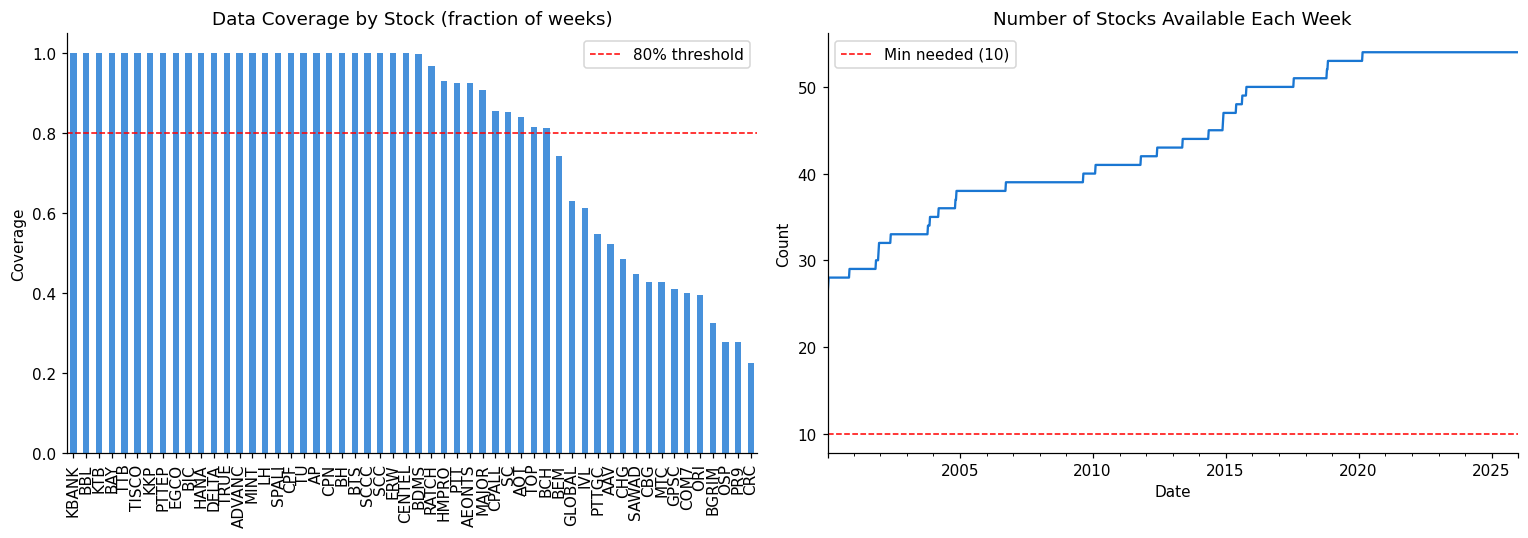

Stocks with >=60% coverage: 41
Available stocks per week (mean): 38.8

First available date per stock:
KBANK    2000-01-14
CPN      2000-01-14
SPALI    2000-01-14
BH       2000-01-14
ERW      2000-01-14
CPF      2000-01-14
TU       2000-01-14
BJC      2000-01-14
MINT     2000-01-14
HANA     2000-01-14
dtype: object


In [2]:
# Coverage per stock
cov = stocks.notna().mean().sort_values(ascending=False)
first_date = stocks.apply(lambda c: c.dropna().index[0] if c.notna().any() else pd.NaT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cov.plot(kind='bar', ax=axes[0], color='#1976D2', alpha=0.8)
axes[0].axhline(0.8, color='red', lw=1, ls='--', label='80% threshold')
axes[0].set_title('Data Coverage by Stock (fraction of weeks)')
axes[0].set_ylabel('Coverage')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)

# Number of stocks available over time
n_stocks = stocks.notna().sum(axis=1)
n_stocks.plot(ax=axes[1], color='#1976D2', lw=1.5)
axes[1].set_title('Number of Stocks Available Each Week')
axes[1].set_ylabel('Count')
axes[1].axhline(LONG_N + SHORT_N, color='red', lw=1, ls='--',
                label=f'Min needed ({LONG_N+SHORT_N})')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGS / 'stock_coverage.png', bbox_inches='tight')
plt.show()

# Use only stocks with >60% coverage for the analysis
stocks_clean = stocks.loc[:, cov >= 0.60]
print(f'Stocks with >=60% coverage: {stocks_clean.shape[1]}')
print(f'Available stocks per week (mean): {stocks_clean.notna().sum(axis=1).mean():.1f}')
print(f'\nFirst available date per stock:')
print(first_date[stocks_clean.columns].sort_values().head(10).dt.date)

---
## Section 3 — Momentum Features

In [3]:
# ── Compute momentum features (all shifted 1 week, no lookahead) ──
mom1  = stocks_clean.shift(1)                          # 1w lag
mom4  = stocks_clean.shift(1).rolling(4, min_periods=3).mean()   # 4w mean
mom12 = stocks_clean.shift(1).rolling(12, min_periods=8).mean()  # 12w mean
mom26 = stocks_clean.shift(1).rolling(26, min_periods=20).mean() # 26w mean
rvol4 = stocks_clean.shift(1).rolling(4, min_periods=3).std()    # 4w vol

# Cross-sectional ranks (0=worst, 1=best) each week
def cs_rank(df):
    return df.rank(axis=1, pct=True, na_option='keep')

r_mom1  = cs_rank(mom1)
r_mom4  = cs_rank(mom4)
r_mom12 = cs_rank(mom12)
r_mom26 = cs_rank(mom26)
r_vol4  = cs_rank(-rvol4)    # lower vol = higher rank (quality filter)

# Forward return (next week's actual return)
fwd1 = stocks_clean.shift(-1)

print('Momentum features computed (all lagged 1w minimum).')
print(f'  mom1  non-null: {mom1.notna().sum().sum():,}')
print(f'  mom4  non-null: {mom4.notna().sum().sum():,}')
print(f'  mom12 non-null: {mom12.notna().sum().sum():,}')

Momentum features computed (all lagged 1w minimum).
  mom1  non-null: 52,591
  mom4  non-null: 52,509
  mom12 non-null: 52,304


---
## Section 4 — IC Analysis: Which Momentum Horizon Predicts Best?

Cross-sectional IC by momentum horizon:


  Mom 1w       IC=+0.0049  std=0.2074  IC+=52.1%  t=+0.88  p=0.3801


  Mom 4w       IC=+0.0159  std=0.2281  IC+=54.4%  t=+2.56  p=0.0107


  Mom 12w      IC=+0.0176  std=0.2316  IC+=54.5%  t=+2.79  p=0.0053


  Mom 26w      IC=+0.0165  std=0.2294  IC+=52.7%  t=+2.63  p=0.0086


  LowVol 4w    IC=-0.0050  std=0.2151  IC+=49.0%  t=-0.86  p=0.3902


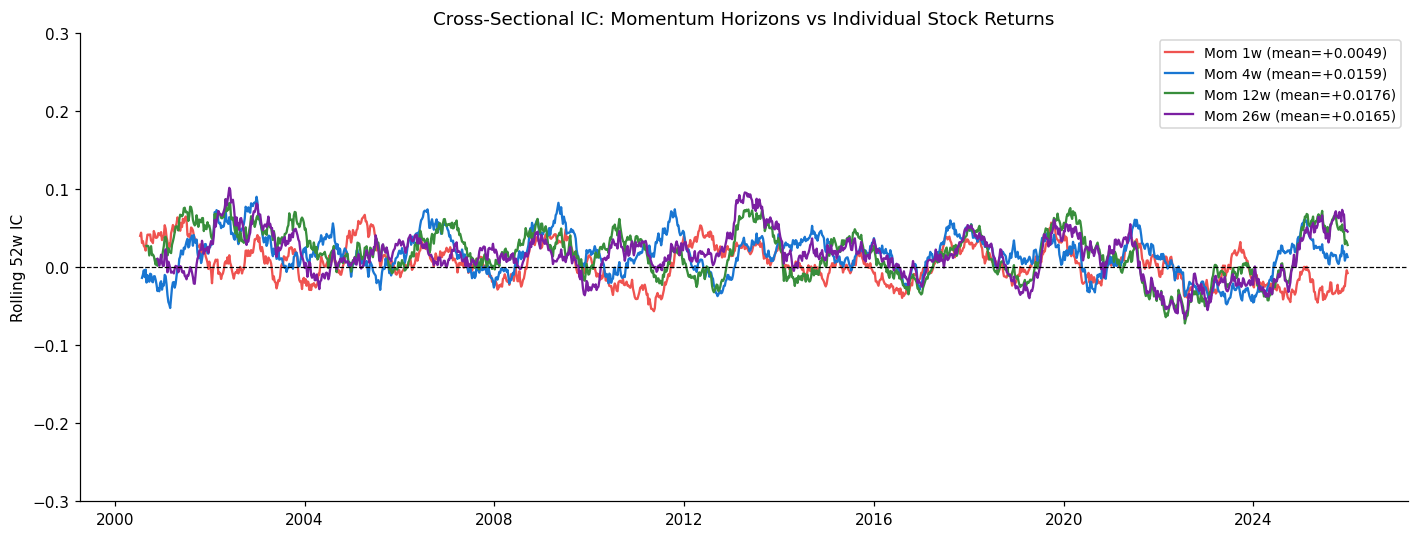

In [4]:
# ── Per-week IC for each feature, then aggregate ──
def rolling_cross_ic(feature_df, fwd_df, label):
    ics = []
    for date in feature_df.index:
        if date not in fwd_df.index: continue
        f = feature_df.loc[date].dropna()
        t = fwd_df.loc[date, f.index].dropna()
        common = f.index.intersection(t.index)
        if len(common) < 10: continue
        ic, _ = spearmanr(f[common], t[common])
        ics.append({'date': date, 'ic': ic})
    s = pd.DataFrame(ics).set_index('date')['ic']
    t_stat, p = ttest_1samp(s.dropna(), 0)
    print(f'  {label:<12} IC={s.mean():+.4f}  std={s.std():.4f}  IC+={( s>0).mean():.1%}  t={t_stat:+.2f}  p={p:.4f}')
    return s

print('Cross-sectional IC by momentum horizon:')
ic_mom1  = rolling_cross_ic(r_mom1,  fwd1, 'Mom 1w')
ic_mom4  = rolling_cross_ic(r_mom4,  fwd1, 'Mom 4w')
ic_mom12 = rolling_cross_ic(r_mom12, fwd1, 'Mom 12w')
ic_mom26 = rolling_cross_ic(r_mom26, fwd1, 'Mom 26w')
ic_vol4  = rolling_cross_ic(r_vol4,  fwd1, 'LowVol 4w')

# Plot rolling 52-week IC
fig, ax = plt.subplots(figsize=(13, 5))
for ic_ser, lbl, col in [
    (ic_mom1,  'Mom 1w',    '#EF5350'),
    (ic_mom4,  'Mom 4w',    '#1976D2'),
    (ic_mom12, 'Mom 12w',   '#388E3C'),
    (ic_mom26, 'Mom 26w',   '#7B1FA2'),
]:
    roll = ic_ser.rolling(52, min_periods=26).mean()
    ax.plot(roll, lw=1.5, color=col, label=f'{lbl} (mean={ic_ser.mean():+.4f})')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('Rolling 52w IC')
ax.set_title('Cross-Sectional IC: Momentum Horizons vs Individual Stock Returns')
ax.legend(fontsize=9)
ax.set_ylim(-0.3, 0.3)
plt.tight_layout()
plt.savefig(FIGS / 'stock_momentum_ic.png', bbox_inches='tight')
plt.show()

---
## Section 5 — Walk-Forward L/S Backtest

In [5]:
# ── Composite momentum score ──
# Weight: 1w reversal gets lower weight (often reversal, not momentum in weekly data)
# Focus on 4w and 12w momentum
def make_composite(items):
    """items: list of (rank_df, weight)"""
    comp = None
    total_w = sum(w for _, w in items)
    for rank_df, w in items:
        comp = rank_df * w if comp is None else comp + rank_df * w
    return comp / total_w

# Main composite: 4w + 12w momentum
comp_score = make_composite([(r_mom4, 0.5), (r_mom12, 0.5)])

def wf_ls_stocks(score_df, fwd_df, long_n=5, short_n=5,
                  min_stocks=15, min_train_weeks=104, fold_size=52, tc=TC):
    """
    Walk-forward cross-sectional L/S on individual stocks.
    Uses score at each date to rank stocks; long top-N, short bottom-N.
    No ML — pure momentum ranking.
    """
    dates = score_df.index
    # Start after min_train_weeks (for IC stability check)
    start_idx = min_train_weeks
    records = []
    prev_longs  = set()
    prev_shorts = set()

    for i in range(start_idx, len(dates)):
        date = dates[i]
        if date not in fwd_df.index: continue

        scores = score_df.loc[date].dropna()
        fwds   = fwd_df.loc[date].dropna()
        valid  = scores.index.intersection(fwds.index)
        scores = scores[valid]; fwds = fwds[valid]

        if len(valid) < min_stocks: continue

        new_longs  = set(scores.nlargest(long_n).index)
        new_shorts = set(scores.nsmallest(short_n).index)

        # TC on position changes
        long_chg  = len((new_longs  ^ prev_longs))
        short_chg = len((new_shorts ^ prev_shorts))
        tc_cost   = (long_chg + short_chg) * tc

        long_ret  = fwds[list(new_longs)].mean()
        short_ret = fwds[list(new_shorts)].mean()
        port_ret  = (long_ret - short_ret) / 2
        bench_ret = fwds.mean()   # equal-weight universe

        # IC this week
        ic = float(spearmanr(scores, fwds)[0]) if len(valid) >= 10 else np.nan

        records.append({'date':date,'gross_ret':port_ret,
                        'net_ret':port_ret - tc_cost,'bench_ret':bench_ret,
                        'long_ret':long_ret,'short_ret':short_ret,
                        'ic':ic,'n_stocks':len(valid),'tc_cost':tc_cost})
        prev_longs  = new_longs
        prev_shorts = new_shorts

    return pd.DataFrame(records).set_index('date')

print('Running walk-forward L/S (composite momentum)...')
res_ls = wf_ls_stocks(comp_score, fwd1)
print(f'OOS weeks: {len(res_ls)}')
print(f'Avg stocks per week: {res_ls["n_stocks"].mean():.1f}')
print(f'Avg TC/yr: {res_ls["tc_cost"].mean()*52:.2%}')

def risk_metrics(rets, freq=52):
    r = pd.Series(rets).dropna()
    if len(r) < 10: return {}
    ann_ret = (1+r).prod()**(freq/len(r)) - 1
    ann_vol = r.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1+r).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'ann_ret':ann_ret,'ann_vol':ann_vol,'sharpe':sharpe,
            'max_dd':max_dd,'win_rate':(r>0).mean(),'n':len(r)}

m = risk_metrics(res_ls['net_ret'])
ic_mean = res_ls['ic'].mean()
ic_pos  = (res_ls['ic'] > 0).mean()
t_ic, p_ic = ttest_1samp(res_ls['ic'].dropna(), 0)
print(f'\nComposite Momentum L/S:')
print(f'  IC mean: {ic_mean:+.4f}  IC+: {ic_pos:.1%}  p={p_ic:.4f}')
print(f'  Gross Sharpe: {risk_metrics(res_ls["gross_ret"])["sharpe"]:+.3f}')
print(f'  Net Sharpe:   {m["sharpe"]:+.3f}')
print(f'  Ann Return:   {m["ann_ret"]:+.2%}')
print(f'  Max DD:       {m["max_dd"]:+.1%}')

Running walk-forward L/S (composite momentum)...


OOS weeks: 1251
Avg stocks per week: 39.6
Avg TC/yr: 40.96%

Composite Momentum L/S:
  IC mean: +0.0186  IC+: 54.6%  p=0.0034
  Gross Sharpe: +0.587
  Net Sharpe:   -2.242
  Ann Return:   -28.77%
  Max DD:       -100.0%


---
## Section 6 — Momentum Variants Comparison

In [6]:
# Compare different momentum specs
specs = {
    'Mom4w only':           make_composite([(r_mom4, 1.0)]),
    'Mom12w only':          make_composite([(r_mom12, 1.0)]),
    'Mom4+12w (50/50)':     make_composite([(r_mom4, 0.5), (r_mom12, 0.5)]),
    'Mom4+12+26':           make_composite([(r_mom4, 0.4), (r_mom12, 0.4), (r_mom26, 0.2)]),
    'Mom+LowVol':           make_composite([(r_mom4, 0.4), (r_mom12, 0.4), (r_vol4, 0.2)]),
    'Mom1w (reversal)':     make_composite([(r_mom1, 1.0)]),
}

print(f'{"Spec":<28} {"Gross Sharpe":>13} {"Net Sharpe":>11} {"AnnRet":>8} {"IC mean":>8} {"p":>8}')
print('-' * 82)
best_spec_name = None
best_spec_sharpe = -999

for spec_name, score_df in specs.items():
    res = wf_ls_stocks(score_df, fwd1)
    mg = risk_metrics(res['gross_ret'])
    mn = risk_metrics(res['net_ret'])
    ic_m = res['ic'].mean()
    _, p = ttest_1samp(res['ic'].dropna(), 0)
    sig = ' *' if p < 0.05 else ''
    print(f'{spec_name:<28} {mg["sharpe"]:>13.3f} {mn["sharpe"]:>11.3f} '
          f'{mn["ann_ret"]:>8.2%} {ic_m:>+8.4f} {p:>8.4f}{sig}')
    if mn.get('sharpe', -999) > best_spec_sharpe:
        best_spec_sharpe = mn['sharpe']
        best_spec_name   = spec_name
        best_score_df    = score_df
        best_res         = res

print(f'\nBest spec: {best_spec_name} (Net Sharpe={best_spec_sharpe:+.3f})')

Spec                          Gross Sharpe  Net Sharpe   AnnRet  IC mean        p
----------------------------------------------------------------------------------


Mom4w only                           0.521      -1.425  -31.22%  +0.0169   0.0068 *


Mom12w only                          0.012      -1.490  -25.08%  +0.0163   0.0115 *


Mom4+12w (50/50)                     0.587      -2.242  -28.77%  +0.0186   0.0034 *


Mom4+12+26                             nan         nan     nan%  +0.0193   0.0029 *


Mom+LowVol                           0.410      -1.485  -28.83%  +0.0201   0.0018 *


Mom1w (reversal)                     0.267      -3.709  -57.91%  +0.0038   0.5086

Best spec: Mom4w only (Net Sharpe=-1.425)


---
## Section 7 — EEM-Gated: Only Run Momentum When EEM+

In [7]:
# EEM gate: only run L/S when EEM signal is positive
eem_pos = (macro['eem_ret_d_lag1'] > 0).reindex(best_score_df.index).fillna(False)

print('Running EEM-gated momentum...')
res_gated = wf_ls_stocks(best_score_df, fwd1)
# Apply EEM gate: zero out returns on EEM- weeks
res_gated_net = res_gated['net_ret'].copy()
res_gated_gross = res_gated['gross_ret'].copy()
eem_mask = eem_pos.reindex(res_gated_net.index).fillna(False).astype(bool)
res_gated_net[~eem_mask]   = 0.0
res_gated_gross[~eem_mask] = 0.0

m_gated   = risk_metrics(res_gated_net)
m_best_ls = risk_metrics(best_res['net_ret'])
print(f'{"Strategy":<30} {"Net Sharpe":>11} {"AnnRet":>9} {"MaxDD":>8}')
print('-' * 62)
print(f'{"Best momentum L/S":<30} {m_best_ls["sharpe"]:>11.3f} {m_best_ls["ann_ret"]:>9.2%} {m_best_ls["max_dd"]:>8.1%}')
print(f'{"EEM-gated momentum":<30} {m_gated["sharpe"]:>11.3f} {m_gated["ann_ret"]:>9.2%} {m_gated["max_dd"]:>8.1%}')
if m_gated['sharpe'] > m_best_ls['sharpe']:
    print('  => EEM gate IMPROVES momentum strategy')
else:
    print('  => EEM gate does not help momentum strategy')

Running EEM-gated momentum...


Strategy                        Net Sharpe    AnnRet    MaxDD
--------------------------------------------------------------
Best momentum L/S                   -1.425   -31.22%  -100.0%
EEM-gated momentum                  -2.081   -19.72%   -99.5%
  => EEM gate does not help momentum strategy


---
## Section 8 — Equity Curves & Verdict

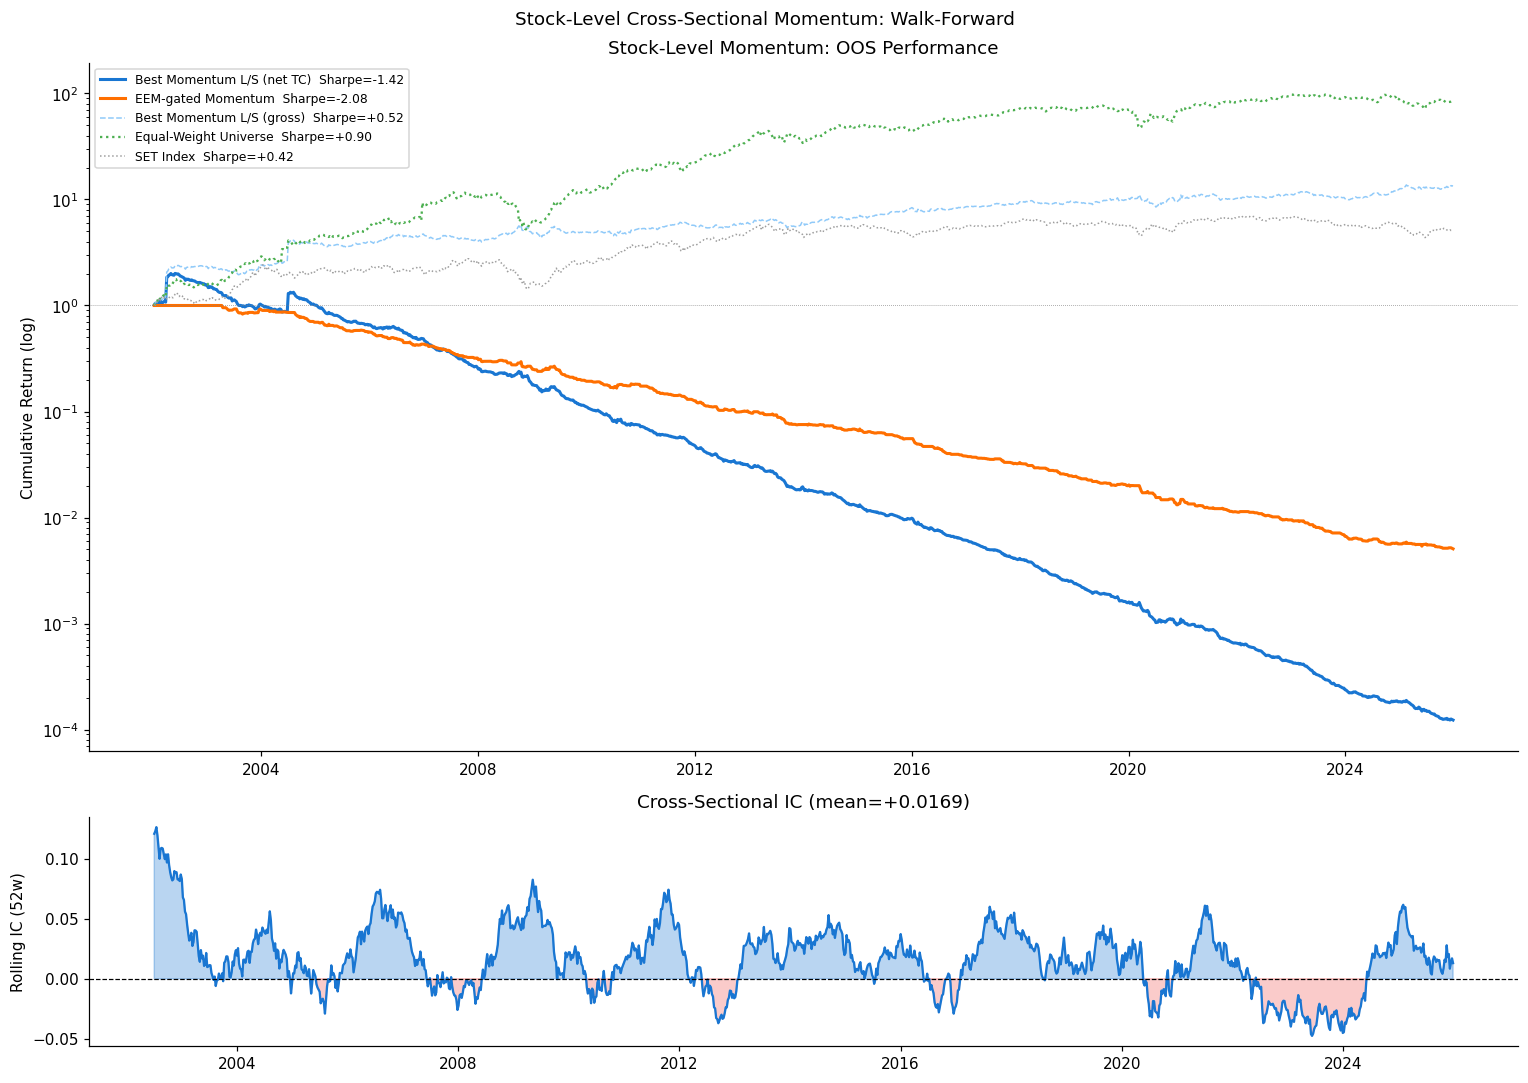

Saved: figs/stock_momentum_equity.png


In [8]:
# ── Equity curves ──
bnh_stocks = res_ls['bench_ret']   # equal-weight universe
set_index  = macro['SET_index_ret_w'].reindex(res_ls.index)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios':[3,1]})
fig.suptitle('Stock-Level Cross-Sectional Momentum: Walk-Forward', fontsize=12)

ax = axes[0]
for rets, lbl, col, lw, ls in [
    (best_res['net_ret'],  f'Best Momentum L/S (net TC)', '#1976D2', 2.0, '-'),
    (res_gated_net,        'EEM-gated Momentum',          '#FF6F00', 2.0, '-'),
    (best_res['gross_ret'],'Best Momentum L/S (gross)',   '#90CAF9', 1.0, '--'),
    (bnh_stocks,           'Equal-Weight Universe',       '#4CAF50', 1.5, ':'),
    (set_index,            'SET Index',                   '#9E9E9E', 1.0, ':'),
]:
    m   = risk_metrics(rets)
    cum = (1 + rets.dropna()).cumprod()
    ax.plot(cum, lw=lw, ls=ls, color=col,
            label=f'{lbl}  Sharpe={m.get("sharpe",0):+.2f}')
ax.axhline(1.0, color='gray', lw=0.5, ls=':')
ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log)')
ax.legend(fontsize=8, loc='upper left')
ax.set_title('Stock-Level Momentum: OOS Performance')

# IC over time
roll_ic = best_res['ic'].rolling(52, min_periods=26).mean()
axes[1].plot(roll_ic, color='#1976D2', lw=1.5)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].fill_between(roll_ic.index, 0, roll_ic,
                     where=roll_ic >= 0, alpha=0.3, color='#1976D2')
axes[1].fill_between(roll_ic.index, 0, roll_ic,
                     where=roll_ic < 0,  alpha=0.3, color='#EF5350')
axes[1].set_ylabel('Rolling IC (52w)')
axes[1].set_title(f'Cross-Sectional IC (mean={best_res["ic"].mean():+.4f})')

plt.tight_layout()
plt.savefig(FIGS / 'stock_momentum_equity.png', bbox_inches='tight')
plt.show()
print('Saved: figs/stock_momentum_equity.png')

In [9]:
# ── Final scorecard ──
ic_ser = best_res['ic'].dropna()
t_ic, p_ic = ttest_1samp(ic_ser, 0)
icir = ic_ser.mean() / ic_ser.std() * np.sqrt(len(ic_ser))
m_net = risk_metrics(best_res['net_ret'])
_, p_ret = ttest_1samp(best_res['net_ret'].dropna(), 0)
annual = best_res['net_ret'].groupby(best_res['net_ret'].index.year).apply(lambda r:(1+r).prod()-1)

evidence = [
    ('IC mean > 0.03',              ic_ser.mean(),         ic_ser.mean() > 0.03),
    ('IC t-test p < 0.05',          p_ic,                  p_ic < 0.05),
    ('ICIR > 0.5',                  icir,                  icir > 0.5),
    ('IC+ fraction > 55%',          (ic_ser>0).mean(),     (ic_ser>0).mean() > 0.55),
    ('Net Sharpe > 0.3',            m_net['sharpe'],       m_net['sharpe'] > 0.3),
    ('Net Sharpe > 0',              m_net['sharpe'],       m_net['sharpe'] > 0),
    ('Annual return > 5%',          m_net['ann_ret'],      m_net['ann_ret'] > 0.05),
    ('Max DD > -40%',               m_net['max_dd'],       m_net['max_dd'] > -0.40),
    ('Positive years > 55%',        (annual>0).mean(),     (annual>0).mean() > 0.55),
    ('Return t-test p < 0.05',      p_ret,                 p_ret < 0.05),
]
score = sum(1 for *_,p in evidence if p)

print('='*65)
print(f'STOCK-LEVEL MOMENTUM VERDICT  [{best_spec_name}]')
print('='*65)
print(f'{"Evidence":<40} {"Value":>10}')
print('-'*55)
for desc, val, passed in evidence:
    mark = '[+]' if passed else '[-]'
    fmt = f'{val:>+10.4f}' if abs(val) < 2 else f'{val:>+10.1%}'
    print(f'{mark} {desc:<40} {fmt}')
print(f'\nScore: {score}/{len(evidence)}')
if score >= 7:   v = 'STRONG — stock-level alpha exists'
elif score >= 5: v = 'MODERATE — viable momentum signal'
elif score >= 3: v = 'WEAK — marginal signal, needs more features'
else:            v = 'NO SIGNAL found with momentum alone'
print(f'=> {v}')

print(f'\nComparison with market/sector strategies:')
print(f'  EEM L/flat (NB16):         Sharpe +0.58')
print(f'  EEM+sector tilt (NB17):    Sharpe +0.62')
print(f'  Stock momentum L/S (NB19): Sharpe {m_net["sharpe"]:+.2f}')
if m_net['sharpe'] > 0.62:
    print('  => Stock-level adds INCREMENTAL ALPHA over market-level strategies')
elif m_net['sharpe'] > 0:
    print('  => Stock-level is positive but does not beat EEM signal alone')
else:
    print('  => Momentum alone insufficient — add financial factors or EEM gate')

STOCK-LEVEL MOMENTUM VERDICT  [Mom4w only]
Evidence                                      Value
-------------------------------------------------------
[-] IC mean > 0.03                              +0.0169
[+] IC t-test p < 0.05                          +0.0068
[+] ICIR > 0.5                                  +271.0%
[-] IC+ fraction > 55%                          +0.5444
[-] Net Sharpe > 0.3                            -1.4250
[-] Net Sharpe > 0                              -1.4250
[-] Annual return > 5%                          -0.3122
[-] Max DD > -40%                               -0.9999
[-] Positive years > 55%                        +0.0417
[+] Return t-test p < 0.05                      +0.0000

Score: 3/10
=> WEAK — marginal signal, needs more features

Comparison with market/sector strategies:
  EEM L/flat (NB16):         Sharpe +0.58
  EEM+sector tilt (NB17):    Sharpe +0.62
  Stock momentum L/S (NB19): Sharpe -1.42
  => Momentum alone insufficient — add financial factors or 